<a href="https://colab.research.google.com/github/aarnav-anand/senseorbit-app/blob/main/CropLens_Training.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# 🌱 CropLens — AI Crop Disease Diagnostics
### Edge-ready MobileNetV2 classifier trained on PlantVillage

This notebook covers the full pipeline:
1. Environment setup
2. Data engineering (PlantVillage dataset + augmentation)
3. Model training (Transfer Learning on MobileNetV2)
4. Validation (Top-1 Accuracy)
5. Optimization (TensorFlow Lite conversion + quantization)
6. Deployment (Streamlit inference app)

**Runtime:** Set `Runtime > Change runtime type > T4 GPU` before running.


## 1️⃣ Environment Setup

In [ ]:
# Install/upgrade required libraries
!pip install -q tensorflow kaggle streamlit pyngrok scikit-learn matplotlib seaborn


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.5/10.5 MB 73.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.4/11.4 MB 69.4 MB/s eta 0:00:00


In [ ]:
import tensorflow as tf
print("TensorFlow version:", tf.__version__)
print("GPU available:", tf.config.list_physical_devices('GPU'))


TensorFlow version: 2.20.0
GPU available: [PhysicalDevice(name='/physical_device:GPU:0', device_type='GPU')]


## 2️⃣ Data Engineering — Download PlantVillage Dataset

In [ ]:
# Upload your kaggle.json (Kaggle Account -> API -> Create New Token)
from google.colab import files
print("Upload your kaggle.json file now:")
uploaded = files.upload()

!mkdir -p ~/.kaggle
!cp kaggle.json ~/.kaggle/
!chmod 600 ~/.kaggle/kaggle.json


Upload your kaggle.json file now:


Saving kaggle.json to kaggle.json


In [ ]:
# Download the PlantVillage dataset (~54,000 labeled leaf images)
!kaggle datasets download -d abdallahalidev/plantvillage-dataset -p /content/data --unzip


Dataset URL: https://www.kaggle.com/datasets/abdallahalidev/plantvillage-dataset
License(s): CC-BY-NC-SA-4.0
100% 2.04G/2.04G [00:19<00:00, 114MB/s]



In [ ]:
# Auto-detect the folder that actually contains class subfolders
import os

candidate_roots = []
for root, dirs, filenames in os.walk('/content/data'):
    # A "class folder" level looks like: many subfolders, each full of images
    if dirs and all(os.path.isdir(os.path.join(root, d)) for d in dirs):
        image_dirs = [d for d in dirs if any(
            f.lower().endswith(('.jpg', '.jpeg', '.png'))
            for f in os.listdir(os.path.join(root, d))[:5]
        )]
        if len(image_dirs) > 5:  # looks like a class-per-folder dataset
            candidate_roots.append((root, len(image_dirs)))

candidate_roots.sort(key=lambda x: -x[1])
DATA_DIR = candidate_roots[0][0] if candidate_roots else None
print("Detected dataset root:", DATA_DIR)
print("Number of classes found:", candidate_roots[0][1] if candidate_roots else 0)


Detected dataset root: /content/data/plantvillage dataset/grayscale
Number of classes found: 38


In [ ]:
# Sanity check: count total images and list a few class names
total_images = 0
class_names = sorted(os.listdir(DATA_DIR))
for c in class_names:
    cpath = os.path.join(DATA_DIR, c)
    if os.path.isdir(cpath):
        n = len(os.listdir(cpath))
        total_images += n

print(f"Total classes: {len(class_names)}")
print(f"Total images: {total_images}")
print("Sample classes:", class_names[:5])


Total classes: 38
Total images: 54305
Sample classes: ['Apple___Apple_scab', 'Apple___Black_rot', 'Apple___Cedar_apple_rust', 'Apple___healthy', 'Blueberry___healthy']


## 3️⃣ Imports & Configuration

In [ ]:
from tensorflow.keras.applications import MobileNetV2
from tensorflow.keras import layers, models, optimizers, callbacks
from tensorflow.keras.preprocessing.image import ImageDataGenerator
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix
import json


In [ ]:
IMG_SIZE = 224
BATCH_SIZE = 32
EPOCHS_HEAD = 10
EPOCHS_FINETUNE = 10
NUM_CLASSES = len(class_names)


## 4️⃣ Data Augmentation & Generators
We deliberately use aggressive augmentation (rotation, zoom, shear, brightness, flips)
so the model tolerates imperfect farmer-taken photos: off-angle shots, poor lighting,
partial blur, and inconsistent framing.

In [ ]:
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=30,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.15,
    zoom_range=0.25,
    horizontal_flip=True,
    vertical_flip=True,
    brightness_range=[0.6, 1.4],
    fill_mode='nearest',
    validation_split=0.2
)

train_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='training',
    shuffle=True,
    seed=42
)

val_gen = train_datagen.flow_from_directory(
    DATA_DIR,
    target_size=(IMG_SIZE, IMG_SIZE),
    batch_size=BATCH_SIZE,
    class_mode='categorical',
    subset='validation',
    shuffle=False,
    seed=42
)

NUM_CLASSES = train_gen.num_classes
class_indices = train_gen.class_indices
print(f"Detected {NUM_CLASSES} classes")

with open('/content/class_indices.json', 'w') as f:
    json.dump(class_indices, f, indent=2)


Found 43456 images belonging to 38 classes.
Found 10849 images belonging to 38 classes.
Detected 38 classes


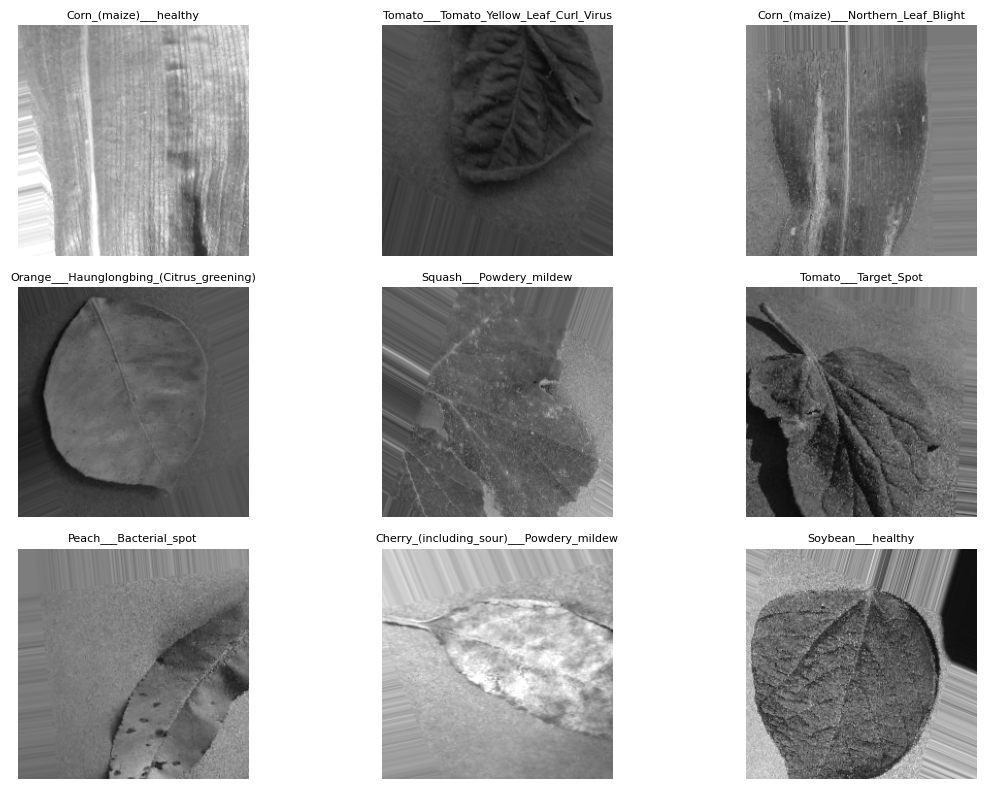

In [ ]:
# Visualize a batch of augmented training images
sample_batch, sample_labels = next(train_gen)
label_names = list(train_gen.class_indices.keys())

plt.figure(figsize=(12, 8))
for i in range(9):
    plt.subplot(3, 3, i + 1)
    plt.imshow(sample_batch[i])
    plt.title(label_names[np.argmax(sample_labels[i])], fontsize=8)
    plt.axis('off')
plt.tight_layout()
plt.show()


## 5️⃣ Model Layer — MobileNetV2 Transfer Learning
We load MobileNetV2 pretrained on ImageNet, freeze the base, and attach a
lightweight classification head. Depthwise separable convolutions keep this
small enough for edge devices.

In [ ]:
base_model = MobileNetV2(
    input_shape=(IMG_SIZE, IMG_SIZE, 3),
    include_top=False,
    weights='imagenet'
)
base_model.trainable = False

inputs = tf.keras.Input(shape=(IMG_SIZE, IMG_SIZE, 3))
x = base_model(inputs, training=False)
x = layers.GlobalAveragePooling2D()(x)
x = layers.Dropout(0.3)(x)
x = layers.Dense(128, activation='relu')(x)
x = layers.Dropout(0.2)(x)
outputs = layers.Dense(NUM_CLASSES, activation='softmax')(x)

model = models.Model(inputs, outputs, name="CropLens_MobileNetV2")
model.summary()


9406464/9406464 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


Model: "CropLens_MobileNetV2"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 224, 224, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ mobilenetv2_1.00_224            │ (None, 7, 7, 1280)     │     2,257,984 │
│ (Functional)                    │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling2d        │ (None, 1280)           │             0 │
│ (GlobalAveragePooling2D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 1280)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │       163,968 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 38)             │         4,902 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,426,854 (9.26 MB)

 Trainable params: 168,870 (659.65 KB)

 Non-trainable params: 2,257,984 (8.61 MB)

In [ ]:
model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-3),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)


In [ ]:
early_stop = callbacks.EarlyStopping(
    monitor='val_accuracy', patience=4, restore_best_weights=True
)
checkpoint = callbacks.ModelCheckpoint(
    '/content/croplens_best.h5', monitor='val_accuracy', save_best_only=True
)
reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_loss', factor=0.5, patience=2, min_lr=1e-6
)


### Phase 1 — Train the classification head (base frozen)

In [ ]:
history_head = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_HEAD,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 437ms/step - accuracy: 0.5539 - loss: 1.6130

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 780s 559ms/step - accuracy: 0.6591 - loss: 1.1449 - val_accuracy: 0.8074 - val_loss: 0.5983 - learning_rate: 0.0010
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 438ms/step - accuracy: 0.7499 - loss: 0.7724

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 746s 549ms/step - accuracy: 0.7536 - loss: 0.7641 - val_accuracy: 0.8165 - val_loss: 0.5396 - learning_rate: 0.0010
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 435ms/step - accuracy: 0.7629 - loss: 0.7270

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 738s 543ms/step - accuracy: 0.7690 - loss: 0.7168 - val_accuracy: 0.8399 - val_loss: 0.4926 - learning_rate: 0.0010
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 740s 545ms/step - accuracy: 0.7794 - loss: 0.6842 - val_accuracy: 0.8283 - val_loss: 0.5078 - learning_rate: 0.0010
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7789 - loss: 0.6773

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 733s 540ms/step - accuracy: 0.7824 - loss: 0.6707 - val_accuracy: 0.8400 - val_loss: 0.4742 - learning_rate: 0.0010
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 432ms/step - accuracy: 0.7912 - loss: 0.6448

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 732s 539ms/step - accuracy: 0.7901 - loss: 0.6470 - val_accuracy: 0.8535 - val_loss: 0.4457 - learning_rate: 0.0010
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 736s 542ms/step - accuracy: 0.7864 - loss: 0.6566 - val_accuracy: 0.8416 - val_loss: 0.4789 - learning_rate: 0.0010
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 734s 540ms/step - accuracy: 0.7934 - loss: 0.6388 - val_accuracy: 0.8525 - val_loss: 0.4493 - learning_rate: 0.0010
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 430ms/step - accuracy: 0.8057 - loss: 0.6010

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 734s 540ms/step - accuracy: 0.8072 - loss: 0.5938 - val_accuracy: 0.8617 - val_loss: 0.4070 - learning_rate: 5.0000e-04
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 733s 540ms/step - accuracy: 0.8058 - loss: 0.5907 - val_accuracy: 0.8612 - val_loss: 0.4045 - learning_rate: 5.0000e-04


### Phase 2 — Fine-tune
Unfreeze the top layers of MobileNetV2 and train with a much lower learning
rate so we adapt the pretrained features to leaf imagery without destroying them.

In [ ]:
base_model.trainable = True
FINE_TUNE_AT = 100  # keep the first 100 layers frozen

for layer in base_model.layers[:FINE_TUNE_AT]:
    layer.trainable = False

model.compile(
    optimizer=optimizers.Adam(learning_rate=1e-5),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history_finetune = model.fit(
    train_gen,
    validation_data=val_gen,
    epochs=EPOCHS_FINETUNE,
    callbacks=[early_stop, checkpoint, reduce_lr]
)


Epoch 1/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 780s 557ms/step - accuracy: 0.6847 - loss: 1.0435 - val_accuracy: 0.8297 - val_loss: 0.5055 - learning_rate: 1.0000e-05
Epoch 2/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 761s 561ms/step - accuracy: 0.7886 - loss: 0.6549 - val_accuracy: 0.8546 - val_loss: 0.4232 - learning_rate: 1.0000e-05
Epoch 3/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 449ms/step - accuracy: 0.8088 - loss: 0.5842

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 755s 556ms/step - accuracy: 0.8100 - loss: 0.5780 - val_accuracy: 0.8747 - val_loss: 0.3604 - learning_rate: 5.0000e-06
Epoch 4/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 442ms/step - accuracy: 0.8230 - loss: 0.5427

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 746s 550ms/step - accuracy: 0.8257 - loss: 0.5312 - val_accuracy: 0.8799 - val_loss: 0.3474 - learning_rate: 5.0000e-06
Epoch 5/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 444ms/step - accuracy: 0.8295 - loss: 0.5131

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 748s 551ms/step - accuracy: 0.8330 - loss: 0.5009 - val_accuracy: 0.8918 - val_loss: 0.3219 - learning_rate: 5.0000e-06
Epoch 6/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 765s 564ms/step - accuracy: 0.8445 - loss: 0.4686 - val_accuracy: 0.8914 - val_loss: 0.3131 - learning_rate: 5.0000e-06
Epoch 7/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 457ms/step - accuracy: 0.8471 - loss: 0.4509

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 768s 566ms/step - accuracy: 0.8481 - loss: 0.4524 - val_accuracy: 0.8981 - val_loss: 0.2974 - learning_rate: 5.0000e-06
Epoch 8/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 450ms/step - accuracy: 0.8553 - loss: 0.4338

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 762s 561ms/step - accuracy: 0.8559 - loss: 0.4286 - val_accuracy: 0.9030 - val_loss: 0.2804 - learning_rate: 5.0000e-06
Epoch 9/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 463ms/step - accuracy: 0.8572 - loss: 0.4227

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 781s 575ms/step - accuracy: 0.8608 - loss: 0.4175 - val_accuracy: 0.9059 - val_loss: 0.2691 - learning_rate: 5.0000e-06
Epoch 10/10
1358/1358 ━━━━━━━━━━━━━━━━━━━━ 0s 455ms/step - accuracy: 0.8652 - loss: 0.4040

1358/1358 ━━━━━━━━━━━━━━━━━━━━ 765s 563ms/step - accuracy: 0.8663 - loss: 0.4008 - val_accuracy: 0.9107 - val_loss: 0.2539 - learning_rate: 5.0000e-06


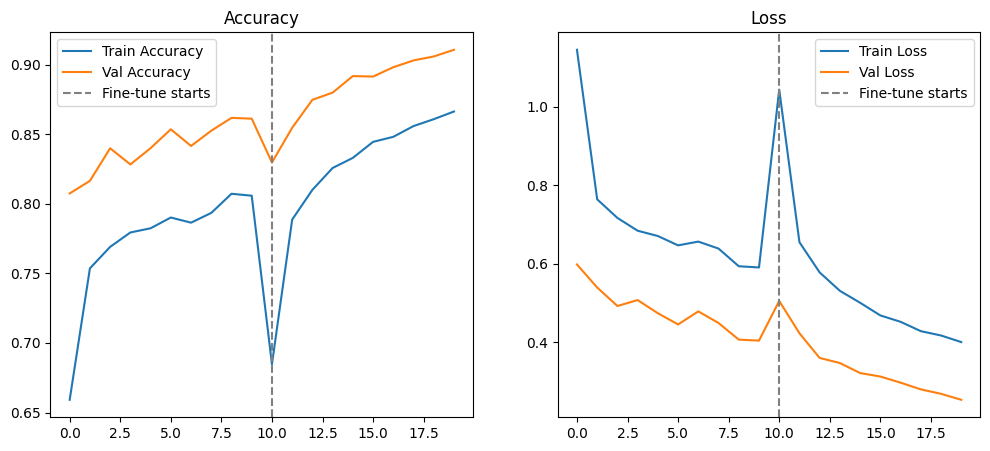

In [ ]:
# Plot training curves (combining both phases)
acc = history_head.history['accuracy'] + history_finetune.history['accuracy']
val_acc = history_head.history['val_accuracy'] + history_finetune.history['val_accuracy']
loss = history_head.history['loss'] + history_finetune.history['loss']
val_loss = history_head.history['val_loss'] + history_finetune.history['val_loss']

plt.figure(figsize=(12, 5))
plt.subplot(1, 2, 1)
plt.plot(acc, label='Train Accuracy')
plt.plot(val_acc, label='Val Accuracy')
plt.axvline(EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tune starts')
plt.legend(); plt.title('Accuracy')

plt.subplot(1, 2, 2)
plt.plot(loss, label='Train Loss')
plt.plot(val_loss, label='Val Loss')
plt.axvline(EPOCHS_HEAD, color='gray', linestyle='--', label='Fine-tune starts')
plt.legend(); plt.title('Loss')
plt.show()


## 6️⃣ Validation — Top-1 Accuracy & Confusion Matrix

In [ ]:
val_gen.reset()
preds = model.predict(val_gen, verbose=1)
y_pred = np.argmax(preds, axis=1)
y_true = val_gen.classes
labels = list(val_gen.class_indices.keys())

top1_acc = np.mean(y_pred == y_true)
print(f"Top-1 Accuracy: {top1_acc * 100:.2f}%")

print(classification_report(y_true, y_pred, target_names=labels))


340/340 ━━━━━━━━━━━━━━━━━━━━ 161s 451ms/step
Top-1 Accuracy: 91.16%
                                                    precision    recall  f1-score   support

                                Apple___Apple_scab       0.89      0.83      0.86       126
                                 Apple___Black_rot       0.88      0.90      0.89       124
                          Apple___Cedar_apple_rust       0.89      0.89      0.89        55
                                   Apple___healthy       0.93      0.96      0.94       329
                               Blueberry___healthy       0.98      0.99      0.99       300
          Cherry_(including_sour)___Powdery_mildew       0.96      0.98      0.97       210
                 Cherry_(including_sour)___healthy       0.99      0.97      0.98       170
Corn_(maize)___Cercospora_leaf_spot Gray_leaf_spot       0.73      0.68      0.70       102
                       Corn_(maize)___Common_rust_       1.00      1.00      1.00       238
           

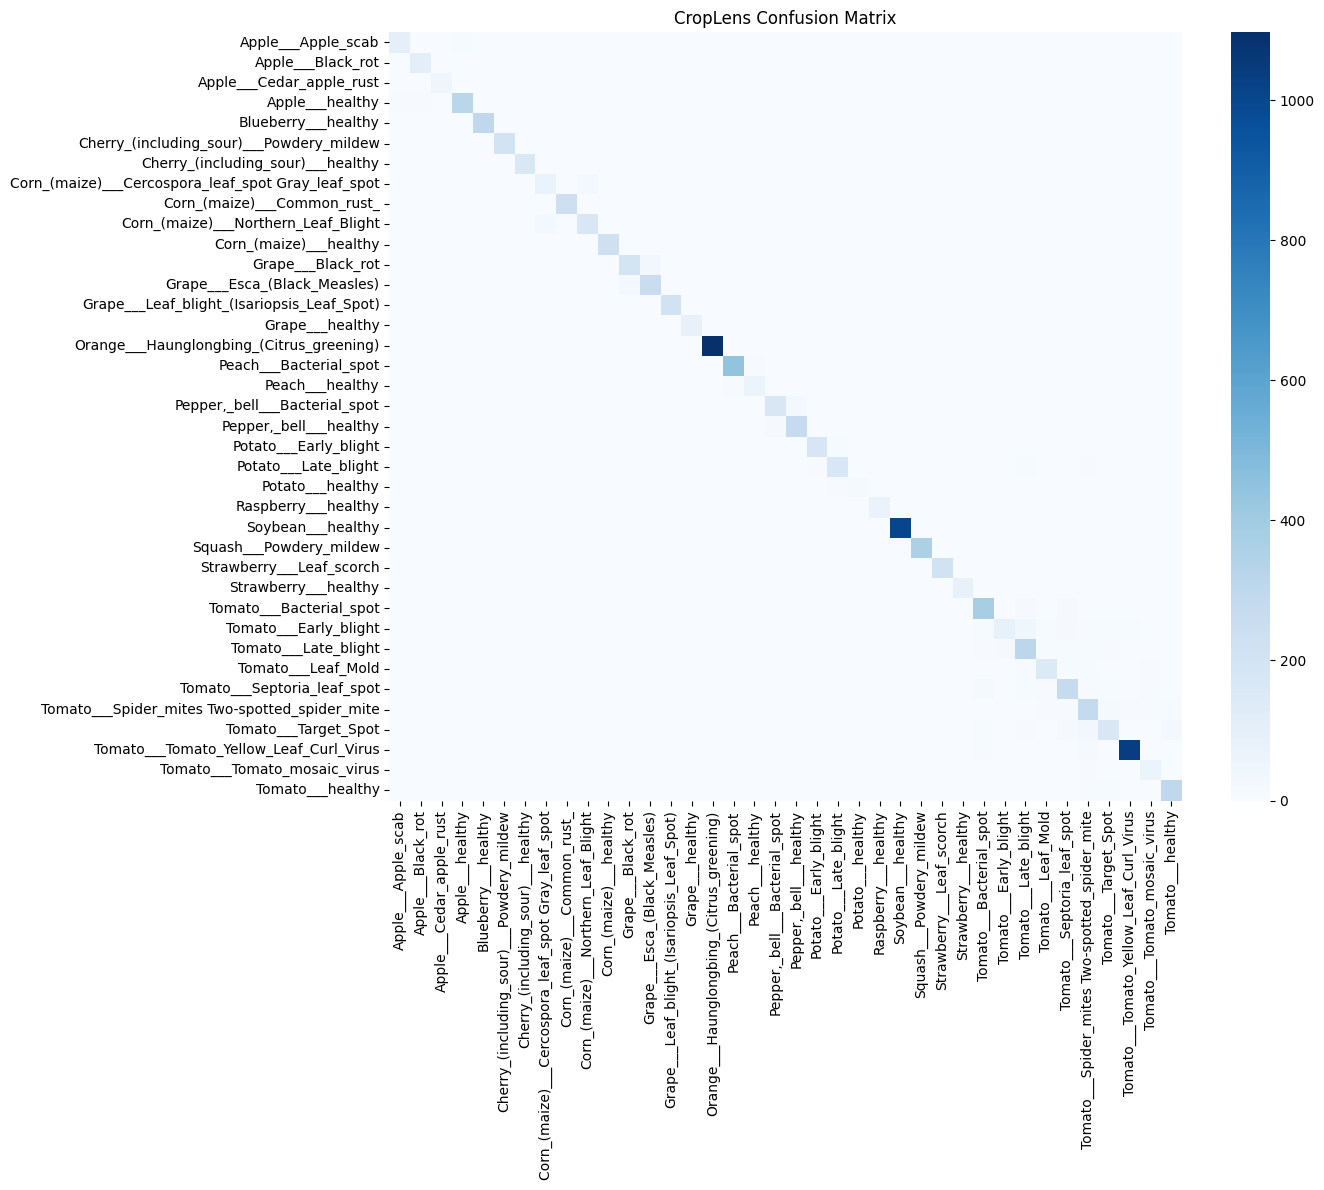

In [ ]:
cm = confusion_matrix(y_true, y_pred)
plt.figure(figsize=(14, 12))
sns.heatmap(cm, cmap='Blues', xticklabels=labels, yticklabels=labels)
plt.xticks(rotation=90)
plt.yticks(rotation=0)
plt.title("CropLens Confusion Matrix")
plt.tight_layout()
plt.show()


## 7️⃣ Save the Trained Model (.h5)

In [ ]:
model.save('/content/croplens_model.h5')
print("Saved: /content/croplens_model.h5")


Saved: /content/croplens_model.h5


## 8️⃣ Optimization Layer — Convert to TensorFlow Lite
We quantize the model (post-training dynamic-range or full-integer quantization
using a representative dataset) to shrink file size for low-power, low-connectivity devices.

In [ ]:
def representative_dataset():
    val_gen.reset()
    for _ in range(100):
        batch, _ = next(val_gen)
        for img in batch:
            yield [np.expand_dims(img, axis=0).astype(np.float32)]

converter = tf.lite.TFLiteConverter.from_keras_model(model)
converter.optimizations = [tf.lite.Optimize.DEFAULT]
converter.representative_dataset = representative_dataset

tflite_model = converter.convert()

with open('/content/croplens_model.tflite', 'wb') as f:
    f.write(tflite_model)

h5_size = os.path.getsize('/content/croplens_model.h5') / (1024 * 1024)
tflite_size = os.path.getsize('/content/croplens_model.tflite') / (1024 * 1024)
print(f".h5 model size:     {h5_size:.2f} MB")
print(f".tflite model size: {tflite_size:.2f} MB  ({(1 - tflite_size/h5_size)*100:.0f}% smaller)")


Saved artifact at '/tmp/tmpkix2jwnm'. The following endpoints are available:

* Endpoint 'serve'
  args_0 (POSITIONAL_ONLY): TensorSpec(shape=(None, 224, 224, 3), dtype=tf.float32, name='keras_tensor_154')
Output Type:
  TensorSpec(shape=(None, 38), dtype=tf.float32, name=None)
Captures:
  136251326050768: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326054032: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326052880: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326053648: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326052688: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326051152: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326053264: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326053072: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326053456: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326053840: TensorSpec(shape=(), dtype=tf.resource, name=None)
  136251326

/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/convert.py:863: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(


.h5 model size:     25.15 MB
.tflite model size: 2.75 MB  (89% smaller)


In [ ]:
# Sanity-check inference with the TFLite model
interpreter = tf.lite.Interpreter(model_path='/content/croplens_model.tflite')
interpreter.allocate_tensors()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()

val_gen.reset()
sample_batch, sample_labels = next(val_gen)
sample_img = np.expand_dims(sample_batch[0], axis=0).astype(np.float32)

interpreter.set_tensor(input_details[0]['index'], sample_img)
interpreter.invoke()
output = interpreter.get_tensor(output_details[0]['index'])

predicted_class = labels[np.argmax(output)]
true_class = labels[np.argmax(sample_labels[0])]
print(f"Predicted: {predicted_class}  |  Actual: {true_class}")


/usr/local/lib/python3.12/dist-packages/tensorflow/lite/python/interpreter.py:457: UserWarning:     Warning: tf.lite.Interpreter is deprecated and is scheduled for deletion in
    TF 2.20. Please use the LiteRT interpreter from the ai_edge_litert package.
    See the [migration guide](https://ai.google.dev/edge/litert/migration)
    for details.
    
  warnings.warn(_INTERPRETER_DELETION_WARNING)


Predicted: Apple___Apple_scab  |  Actual: Apple___Apple_scab


## 9️⃣ Treatment Protocol Map
This auto-generates a **placeholder** treatment-advice file keyed by class name.
⚠️ Replace these generic placeholders with agronomist-verified, region-specific
guidance before using this with real farmers — the AI identifies the disease,
it does not replace expert treatment advice.

In [ ]:
disease_classes = list(train_gen.class_indices.keys())
treatment_map = {}

for cls in disease_classes:
    if "healthy" in cls.lower():
        advice = ("No disease detected. Continue regular monitoring, proper spacing, "
                   "and good field hygiene.")
    else:
        advice = ("Possible infection detected. Suggested first steps: "
                   "(1) Remove and isolate the most affected leaves, "
                   "(2) improve air circulation and avoid overhead watering, "
                   "(3) contact your local agricultural extension officer for a "
                   "targeted, regionally-approved treatment plan. "
                   "[Placeholder — replace with agronomist-verified guidance for this disease.]")
    treatment_map[cls] = advice

with open('/content/treatment_map.json', 'w') as f:
    json.dump(treatment_map, f, indent=2)

print(f"Generated placeholder treatment map for {len(treatment_map)} classes")


Generated placeholder treatment map for 38 classes


## 🔟 Deployment Layer — Streamlit Inference App

In [ ]:
%%writefile app.py
import streamlit as st
import tensorflow as tf
import numpy as np
from PIL import Image
import json

st.set_page_config(page_title="CropLens - AI Crop Doctor", page_icon="🌱", layout="centered")

@st.cache_resource
def load_model():
    interpreter = tf.lite.Interpreter(model_path="croplens_model.tflite")
    interpreter.allocate_tensors()
    return interpreter

@st.cache_resource
def load_labels():
    with open("class_indices.json") as f:
        class_indices = json.load(f)
    return {v: k for k, v in class_indices.items()}

@st.cache_resource
def load_treatments():
    with open("treatment_map.json") as f:
        return json.load(f)

interpreter = load_model()
labels = load_labels()
treatments = load_treatments()
input_details = interpreter.get_input_details()
output_details = interpreter.get_output_details()
IMG_SIZE = input_details[0]["shape"][1]

st.title("🌱 CropLens: AI Crop Doctor")
st.write("Upload a photo of a crop leaf to get an instant AI-assisted diagnosis.")

uploaded_file = st.file_uploader("Upload a leaf image", type=["jpg", "jpeg", "png"])

if uploaded_file:
    image = Image.open(uploaded_file).convert("RGB")
    st.image(image, caption="Uploaded Image", use_container_width=True)

    img = image.resize((IMG_SIZE, IMG_SIZE))
    img_array = np.array(img).astype(np.float32) / 255.0
    img_array = np.expand_dims(img_array, axis=0)

    interpreter.set_tensor(input_details[0]["index"], img_array)
    interpreter.invoke()
    output = interpreter.get_tensor(output_details[0]["index"])[0]

    top_idx = int(np.argmax(output))
    confidence = float(output[top_idx]) * 100
    disease_name = labels[top_idx]
    readable_name = disease_name.replace("___", " - ").replace("_", " ")

    st.subheader("Diagnosis")
    st.write(f"**{readable_name}**")
    st.write(f"Confidence: {confidence:.2f}%")

    if confidence < 60:
        st.warning("Low confidence — try retaking the photo with better lighting and a closer, "
                    "well-framed shot of the leaf.")

    st.subheader("Recommended Next Steps")
    advice = treatments.get(disease_name, "No specific protocol found. Please consult a local agronomist.")
    st.info(advice)

    st.caption("⚠️ CropLens is an AI-assisted screening tool, not a substitute for professional agronomic advice.")


Overwriting app.py


In [ ]:
!pkill -f streamlit

In [ ]:
# Launch the app with a public tunnel (get a free token at https://dashboard.ngrok.com)
from pyngrok import ngrok

NGROK_AUTH_TOKEN = "3HaBe09QAWAr0dqKm1otDcQ0vgi_5EajgKptNsKWT1WaUQvGV"
ngrok.set_auth_token(NGROK_AUTH_TOKEN)

public_url = ngrok.connect(8501)
print("CropLens app URL:", public_url)

get_ipython().system_raw('streamlit run app.py &>/content/logs.txt &')


CropLens app URL: NgrokTunnel: "https://anemic-mobile-snap.ngrok-free.dev" -> "http://localhost:8501"


## 1️⃣1️⃣ Package Deliverables

In [ ]:
!zip -r /content/croplens_deliverables.zip \
    /content/croplens_model.tflite \
    /content/class_indices.json \
    /content/treatment_map.json \
    /content/app.py

from google.colab import files
files.download('/content/croplens_deliverables.zip')


  adding: content/croplens_model.tflite (deflated 18%)
  adding: content/class_indices.json (deflated 62%)
  adding: content/treatment_map.json (deflated 93%)
  adding: content/app.py (deflated 54%)


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>